In [1]:
import os
import glob

import numpy as np
import polars as pl
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score, accuracy_score, roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay, precision_recall_fscore_support, classification_report

from itertools import cycle

In [2]:
WORKING_DIR = '/group/pmc021/amunif/epi-thesis/workflow/08_HepG2/'
OUTPUT_DIR = os.path.join(WORKING_DIR, 'output', 'quantile_label')

In [3]:
# Check CUDA device
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cuda device


# Load the Dataset

## Load the dataset with quantile label

In [4]:
gene_pl = pl.read_parquet(os.path.join(WORKING_DIR, 'dataset', f'gene_w_qlabel.parquet'))

In [5]:
gene_pl.head(5)

gene_id,H3K4me3,H3K4me3_count,H3K9ac,H3K9ac_count,H3K9me3,H3K9me3_count,H3K27ac,H3K27ac_count,H3K27me3,H3K27me3_count,value_1,label
str,list[f64],i64,list[f64],i64,list[f64],i64,list[f64],i64,list[f64],i64,f64,i64
"""XLOC_000001""","[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,0.0,0
"""XLOC_000003""","[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,0.0,0
"""XLOC_000006""","[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,0.0888452,1
"""XLOC_000007""","[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,4.04743,2
"""XLOC_000008""","[0.0, 0.0, … 0.0]",6,"[0.0, 0.0, … 0.0]",3,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",2,"[0.0, 0.0, … 0.0]",0,26.7934,3


In [6]:
# Check the label distribution
gene_pl.group_by("label").len()

label,len
i64,u32
0,5539
2,5538
3,5539
1,5538


## Reformat the histone column

In [7]:
markers = ['H3K4me3', 'H3K9ac', 'H3K9me3', 'H3K27ac', 'H3K27me3']

In [8]:
# Create dataframe based on histone marker permutation item
gene_perm_pl = gene_pl.with_columns(
    pl.struct(markers).map_elements(
        lambda x: [x[col_name] for col_name in markers],
        return_dtype = pl.List(pl.List(pl.Float64))
    )
    .alias('histone')
)

In [9]:
gene_perm_pl

gene_id,H3K4me3,H3K4me3_count,H3K9ac,H3K9ac_count,H3K9me3,H3K9me3_count,H3K27ac,H3K27ac_count,H3K27me3,H3K27me3_count,value_1,label,histone
str,list[f64],i64,list[f64],i64,list[f64],i64,list[f64],i64,list[f64],i64,f64,i64,list[list[f64]]
"""XLOC_000001""","[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,0.0,0,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]"
"""XLOC_000003""","[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,0.0,0,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]"
"""XLOC_000006""","[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,0.0888452,1,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]"
"""XLOC_000007""","[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,4.04743,2,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]"
"""XLOC_000008""","[0.0, 0.0, … 0.0]",6,"[0.0, 0.0, … 0.0]",3,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",2,"[0.0, 0.0, … 0.0]",0,26.7934,3,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]"
…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""XLOC_030009""","[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,0.0,0,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]"
"""XLOC_030012""","[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,0.0,0,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]"
"""XLOC_030014""","[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,0.0,0,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]"


# Data Preparation for Deep Learning

In [10]:
# Select X and y column
X = gene_perm_pl.select(pl.col('histone')).to_series().to_list()
y = gene_perm_pl.select(pl.col('label')).to_series().to_list()

In [11]:
# Convert to Numpy array
X = np.array(X)
y = np.array(y)

## Split the dataset into training, validation, and test sets

In [12]:
# Split the dataset into training, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.666, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

In [13]:
print("Train set shape:", X_train.shape, y_train.shape)
print("Validation set shape:", X_val.shape, y_val.shape)
print("Test set shape:", X_test.shape, y_test.shape)

Train set shape: (7399, 5, 4000) (7399,)
Validation set shape: (7377, 5, 4000) (7377,)
Test set shape: (7378, 5, 4000) (7378,)


## Convert to Tensor

In [14]:
# Convert numpy arrays to PyTorch tensors
X_train = torch.from_numpy(X_train).float().unsqueeze(1).to(device)
X_val = torch.from_numpy(X_val).float().unsqueeze(1).to(device)
X_test = torch.from_numpy(X_test).float().unsqueeze(1).to(device)

y_train = torch.from_numpy(y_train).float().to(device)
y_val = torch.from_numpy(y_val).float().to(device)
y_test = torch.from_numpy(y_test).float().to(device)

## Create Data Loader

In [15]:
# Create DataLoaders
batch_size = 32

train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

val_dataset = TensorDataset(X_val, y_val)
val_loader = DataLoader(val_dataset, batch_size=batch_size)

test_dataset = TensorDataset(X_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

# Deep Classifier Class

Updated so it can handle multiclass classification

In [16]:
# Define DeepClassifer Class
class DeepClassifier(nn.Module):
    def __init__(self, input_dim = [5, 4000], out_channels = 50, conv_kernel_size = 10, max_pooling_kernel_size = 5,
                 num_classes = 4):
        super(DeepClassifier, self).__init__()
        
        flatten_dim = out_channels * ((input_dim[1] - conv_kernel_size + 1) // max_pooling_kernel_size)

        self.conv = nn.Conv2d(1, out_channels, kernel_size=(input_dim[0], conv_kernel_size))
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d((1, max_pooling_kernel_size))
        self.dropout = nn.Dropout(0.5)
        self.flatten = nn.Flatten()
        self.linear1 = nn.Linear(flatten_dim, 625)
        self.linear2 = nn.Linear(625, 125)
        self.linear3 = nn.Linear(125, num_classes)
        # self.softmax = nn.LogSoftmax(dim=1) # Removing LogSoftmax as right now we have multiclass classification
        

    def forward(self, x):
        # Stage 1: filter bank -> squashing -> max pooling
        x = self.conv(x)
        x = self.relu(x)
        x = self.pool(x)

        # Stage 2: standar 2-layer neural network        
        x = self.flatten(x)
        x = self.dropout(x)
        x = self.linear1(x)
        x = self.relu(x)
        x = self.linear2(x)
        x = self.relu(x)
        x = self.linear3(x)
        # x = self.softmax(x) # Removing LogSoftmax as right now we have multilcass classification
        return x

# Modeling

## Define model instance

In [17]:
n_rows_item = len(markers)
item_name = '-'.join(markers)
print(n_rows_item)
print(item_name)

5
H3K4me3-H3K9ac-H3K9me3-H3K27ac-H3K27me3


In [18]:
# Initialize the model
# Change the criterion to CrossEntryLoss for multiclass classification

num_classes = 4
optimizer_name = "Adam"

model = DeepClassifier(input_dim = [n_rows_item, 4000], num_classes = num_classes).to(device)
criterion = nn.CrossEntropyLoss()

sgd_optimizer = optim.SGD(
    model.parameters(), 
    lr=0.01,
    momentum=0.9,
    weight_decay=1e-5,
    nesterov=True
)

adam_optimizer = optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-5
)

if optimizer_name == 'SGD':
    optimizer = sgd_optimizer
elif optimizer_name == 'Adam':
    optimizer = adam_optimizer

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.1,
    patience=5,
)

num_epochs = 100

# For tracking train and validation
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []
train_aucs, val_aucs = [], []
val_precisions = []
val_recalls = []
val_f1_scores = []

# For saving the best model
best_val_metric = float('-inf')
best_model_path = os.path.join(OUTPUT_DIR, "experiments", "model", f'{item_name}-{optimizer_name}.pth')

## Training Phase

In [19]:
# Run the training and validation phase
for epoch in range(num_epochs):
    # Training phase
    model.train()  # Set the model to training mode
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    train_true_labels = []
    train_predicted_probs = []
    
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs.cuda(), labels.type(torch.LongTensor).cuda())
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

        # Add this so it can handle the multiclass classification
        probs = F.softmax(outputs, dim = 1)
        
        _, predicted = torch.max(outputs.data, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

        train_true_labels.extend(labels.cpu().numpy())
        train_predicted_probs.extend(probs.detach().cpu().numpy())
    
    avg_train_loss = train_loss / len(train_loader)
    train_accuracy = 100 * train_correct / train_total

    train_true_labels = np.array(train_true_labels)
    train_predicted_probs = np.array(train_predicted_probs)
    train_auc_score = roc_auc_score(train_true_labels, train_predicted_probs, multi_class='ovr', average='macro')
    
    train_losses.append(round(avg_train_loss, 4))
    train_accuracies.append(round(train_accuracy, 2))
    train_aucs.append(round(train_auc_score, 2))
    
    # Validation phase
    model.eval()  # Set the model to evaluation mode
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    val_metric = 0
    val_true_labels = []
    val_predicted_probs = []
    val_predicted_labels = []
    
    with torch.no_grad():  # Disable gradient computation
        for inputs, labels in val_loader:
            outputs = model(inputs)
            loss = criterion(outputs.cuda(), labels.type(torch.LongTensor).cuda())
            val_loss += loss.item()

            probs = F.softmax(outputs, dim = 1)
            
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

            val_true_labels.extend(labels.cpu().numpy())
            val_predicted_probs.extend(probs.detach().cpu().numpy())
            val_predicted_labels.extend(predicted.cpu().numpy())

    # Convert lists to numpy arrays
    val_true_labels = np.array(val_true_labels)
    val_predicted_probs = np.array(val_predicted_probs)
    val_predicted_labels = np.array(val_predicted_labels)

    # Calculate precision, recall, and F1-score
    precision, recall, f1_score, _ = precision_recall_fscore_support(
        val_true_labels, 
        val_predicted_labels, 
        average='macro'  # Use macro average for multi-class classification
    )
    
    avg_val_loss = val_loss / len(val_loader)
    val_accuracy = 100 * val_correct / val_total
    val_metric = val_correct / len(val_loader)

    # Save the best model
    if val_metric > best_val_metric:
        best_val_metric = val_metric
        torch.save(model.state_dict(), best_model_path)
        print(f"New best model saved with validation metric: {best_val_metric:.4f}")
    
    val_true_labels = np.array(val_true_labels)
    val_predicted_probs = np.array(val_predicted_probs)
    val_auc_score = roc_auc_score(val_true_labels, val_predicted_probs, multi_class='ovr', average='macro')

    val_losses.append(round(avg_val_loss, 4))
    val_accuracies.append(round(val_accuracy, 2))
    val_aucs.append(round(val_auc_score, 2))
    val_precisions.append(round(precision, 2))
    val_recalls.append(round(recall, 2))
    val_f1_scores.append(round(f1_score, 2))

    # Learning rate scheduling
    scheduler.step(avg_val_loss)
    
    print(f'Epoch [{epoch+1}/{num_epochs}] - '
          f'[TRAIN] Loss: {avg_train_loss:.4f}, Accuracy: {train_accuracy:.2f}% - '
          f'[VAL] Loss: {avg_val_loss:.4f}, Accuracy: {val_accuracy:.2f}%, '
          f'Precision: {precision:.2f}, Recall: {recall:.2f}, F1-Score: {f1_score:.2f}, '
          f'AUC: {val_auc_score:.2f}')

print("Training finished!")

New best model saved with validation metric: 14.4156
Epoch [1/100] - [TRAIN] Loss: 1.2024, Accuracy: 43.59% - [VAL] Loss: 1.1874, Accuracy: 45.14%, Precision: 0.44, Recall: 0.45, F1-Score: 0.38, AUC: 0.72
Epoch [2/100] - [TRAIN] Loss: 1.1657, Accuracy: 47.29% - [VAL] Loss: 1.1898, Accuracy: 44.80%, Precision: 0.44, Recall: 0.45, F1-Score: 0.39, AUC: 0.72
New best model saved with validation metric: 14.5584
Epoch [3/100] - [TRAIN] Loss: 1.1321, Accuracy: 48.94% - [VAL] Loss: 1.2190, Accuracy: 45.59%, Precision: 0.45, Recall: 0.46, F1-Score: 0.41, AUC: 0.71
Epoch [4/100] - [TRAIN] Loss: 1.0760, Accuracy: 52.89% - [VAL] Loss: 1.2231, Accuracy: 45.09%, Precision: 0.44, Recall: 0.45, F1-Score: 0.43, AUC: 0.71
Epoch [5/100] - [TRAIN] Loss: 0.9911, Accuracy: 57.32% - [VAL] Loss: 1.3183, Accuracy: 43.34%, Precision: 0.41, Recall: 0.43, F1-Score: 0.41, AUC: 0.69
Epoch [6/100] - [TRAIN] Loss: 0.8861, Accuracy: 62.79% - [VAL] Loss: 1.3879, Accuracy: 43.24%, Precision: 0.42, Recall: 0.43, F1-Score

## Testing Phase

In [23]:
# Load the best model
best_model = DeepClassifier(input_dim = [n_rows_item, 4000]).to(device)
best_model.load_state_dict(torch.load(best_model_path))
best_model.eval()

# Predict on test set
test_predictions = []
test_true_labels = []
test_predicted_probs = []

with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = best_model(inputs)

        probabilities = F.softmax(outputs, dim = 1)
        
        _, predicted = torch.max(outputs.data, 1)
        test_predictions.extend(predicted.cpu().numpy())
        test_true_labels.extend(labels.cpu().numpy())
        test_predicted_probs.extend(probabilities.cpu().numpy())

# Convert lists to numpy arrays
test_predictions = np.array(test_predictions)
test_true_labels = np.array(test_true_labels)
test_predicted_probs = np.array(test_predicted_probs)

# Calculate evaluation metric
# Precision, Recall, F1-Score
precision, recall, f1_score, _ = precision_recall_fscore_support(
    test_true_labels, 
    test_predictions, 
    average='macro'  # Use 'macro' for multi-class
)

test_acc_score = round(accuracy_score(test_true_labels, test_predictions) * 100, 2)
print(f"Accuracy Score on test set: {test_acc_score:.2f} %")

test_auc_score = round(roc_auc_score(test_true_labels, test_predicted_probs, multi_class='ovr', average='macro'), 2)
print(f"AUC Score on test set: {test_auc_score:.2f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1_score:.4f}")

# Detailed classification report
print("\nDetailed Classification Report:")
print(classification_report(test_true_labels, test_predictions))

# Confusion Matrix
conf_matrix = confusion_matrix(test_true_labels, test_predictions)
print("\nConfusion Matrix:")
print(conf_matrix)

Accuracy Score on test set: 45.08 %
AUC Score on test set: 0.71
Precision: 0.4372
Recall: 0.4508
F1-Score: 0.4081

Detailed Classification Report:
              precision    recall  f1-score   support

         0.0       0.52      0.73      0.61      1844
         1.0       0.44      0.16      0.23      1844
         2.0       0.37      0.20      0.26      1845
         3.0       0.42      0.71      0.53      1845

    accuracy                           0.45      7378
   macro avg       0.44      0.45      0.41      7378
weighted avg       0.44      0.45      0.41      7378


Confusion Matrix:
[[1350  170  104  220]
 [ 791  294  256  503]
 [ 274  133  373 1065]
 [ 189   78  269 1309]]


## Draw the training graph

In [21]:
def plot_metrics(train_losses, val_losses, train_accuracies, val_accuracies, kernel_size=10, pool_size=5):
    epochs = range(1, len(train_losses) + 1)
    
    plt.figure(figsize=(14, 6))
    
    # Plot for training and validation Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, 'blue', label='Training Loss')
    plt.plot(epochs, val_losses, 'orange', label='Validation Loss')
    plt.title(f'Training and Validation Loss - {optimizer_name} Optimizer, kernel_size = {kernel_size}, pool_size = {pool_size}')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    # Plot for training and validation Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accuracies, 'blue', label='Training Accuracy')
    plt.plot(epochs, val_accuracies, 'orange', label='Validation Accuracy')
    plt.title(f'Training and Validation Accuracy - {optimizer_name} Optimizer, kernel_size = {kernel_size}, pool_size = {pool_size}')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()

    img_name = f"{item_name}-{optimizer_name}.png"
    plt.savefig(os.path.join(OUTPUT_DIR, 'img', 'train', img_name))
    
    plt.show()

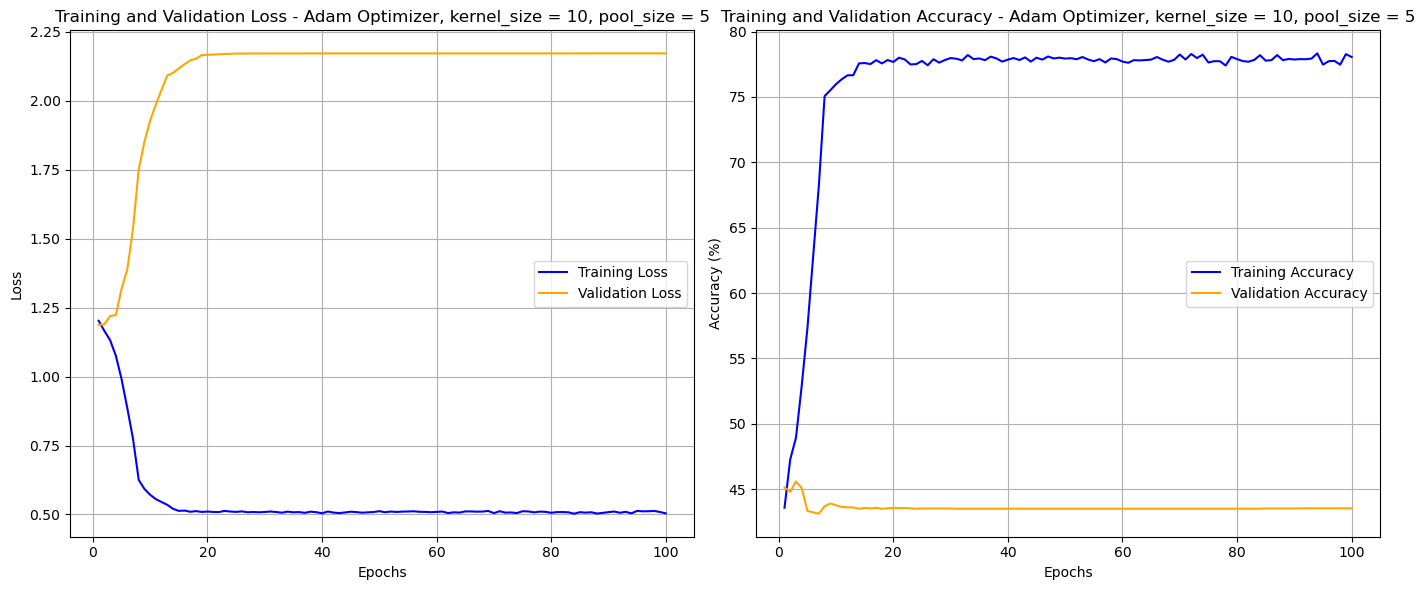

In [22]:
plot_metrics(train_losses, val_losses, train_accuracies, val_accuracies)

## Drawing the confusion matrix

In [24]:
# Get the class labels
class_labels = np.unique(test_true_labels)
print(class_labels)

[0. 1. 2. 3.]


In [25]:
# Create the confusion matrix
cm = confusion_matrix(test_true_labels, test_predictions, labels=class_labels)

In [26]:
# Create a ConfusionMatrixDisplay object
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)

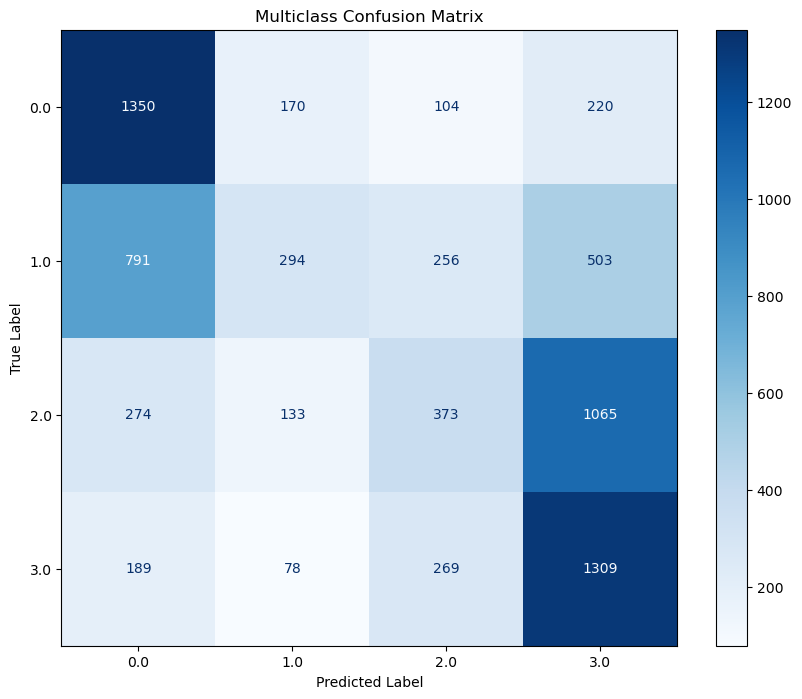

In [27]:
# Plot the confusion matrix
fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, cmap=plt.cm.Blues, values_format='d')

# Customize the plot
plt.title('Multiclass Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

img_name = f"{item_name}-{optimizer_name}.png"
plt.savefig(os.path.join(OUTPUT_DIR, 'img', 'confusion_matrix', img_name))

# Show the plot
plt.show()

## Drawing ROC Curve

In [28]:
# Binarize the labels
n_classes = len(np.unique(test_true_labels))
y_true_bin = label_binarize(test_true_labels, classes=range(n_classes))

In [29]:
test_predicted_probs

array([[0.6363371 , 0.3484088 , 0.01228756, 0.00296648],
       [0.01351743, 0.07317678, 0.2832312 , 0.63007456],
       [0.09807304, 0.4694598 , 0.31703544, 0.11543171],
       ...,
       [0.04204461, 0.19902147, 0.21241634, 0.54651755],
       [0.046462  , 0.25622237, 0.39259952, 0.30471617],
       [0.02201272, 0.13163997, 0.522923  , 0.32342428]], dtype=float32)

In [30]:
# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], test_predicted_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

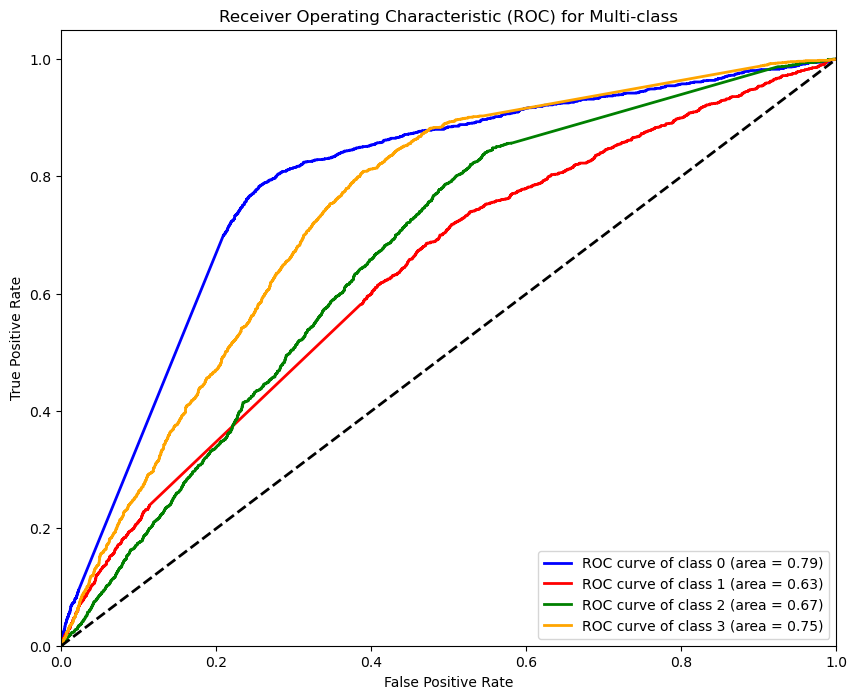

In [31]:
# Plot ROC curves
plt.figure(figsize=(10, 8))
colors = cycle(['blue', 'red', 'green', 'orange', 'purple'])
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC curve of class {0} (area = {1:0.2f})'
             ''.format(i, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) for Multi-class')
plt.legend(loc="lower right")

img_name = f"{item_name}-{optimizer_name}.png"
plt.savefig(os.path.join(OUTPUT_DIR, 'img', 'roc', img_name))

plt.show()

In [32]:
# Print AUC scores
for i in range(n_classes):
    print(f"AUC for class {i}: {roc_auc[i]:.2f}")

AUC for class 0: 0.79
AUC for class 1: 0.63
AUC for class 2: 0.67
AUC for class 3: 0.75


In [33]:
# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), test_predicted_probs.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
print(f"Micro-average AUC: {roc_auc['micro']:.2f}")

Micro-average AUC: 0.72


# Saving the experiment results

## Detailed Experiments

In [ ]:
# Create dataframe from array
experiment_results = {
    'train_loss': train_losses,
    'train_accuracy': train_accuracies,
    'train_auc': train_aucs,
    'val_loss': val_losses,
    'val_accuracy': val_accuracies,
    'val_auc': val_aucs
}

In [ ]:
experiment_pl = pl.DataFrame(experiment_results)

In [ ]:
experiment_pl.write_csv(os.path.join(OUTPUT_DIR, 'experiments', 'details', f'{item_name}-{optimizer_name}.csv'))

## Min, Avg, Max

In [ ]:
def min_avg_max(lst):
    return round(min(lst), 2), round(sum(lst)/len(lst), 2), round(max(lst), 2)

In [ ]:
train_loss_min, train_loss_avg, train_loss_max = min_avg_max(train_losses)
train_acc_min, train_acc_avg, train_acc_max = min_avg_max(train_accuracies)
train_auc_min, train_auc_avg, train_auc_max = min_avg_max(train_aucs)

print(f"{train_loss_min:.2f}, {train_loss_avg:.2f}, {train_loss_max:.2f}")
print(f"{train_acc_min}, {train_acc_avg}, {train_acc_max}")
print(f"{train_auc_min}, {train_auc_avg}, {train_auc_max}")

In [ ]:
val_loss_min, val_loss_avg, val_loss_max = min_avg_max(val_losses)
val_acc_min, val_acc_avg, val_acc_max = min_avg_max(val_accuracies)
val_auc_min, val_auc_avg, val_auc_max = min_avg_max(val_aucs)

print(f"{val_loss_min:.2f}, {val_loss_avg:.2f}, {val_loss_max:.2f}")
print(f"{val_acc_min}, {val_acc_avg}, {val_acc_max}")
print(f"{val_auc_min}, {val_auc_avg}, {val_auc_max}")

In [ ]:
print(f"{test_acc_score}, {test_auc_score}")

In [ ]:
# Prepare the output file
output_rows = []

output_rows.append([
    item_name,
    train_loss_min, train_loss_avg, train_loss_max,
    train_acc_min, train_acc_avg, train_acc_max,
    train_auc_min, train_auc_avg, train_auc_max,
    val_loss_min, val_loss_avg, val_loss_max,
    val_acc_min, val_acc_avg, val_acc_max,
    val_auc_min, val_auc_avg, val_auc_max,
    test_acc_score, test_auc_score
])

output_rows_df = pd.DataFrame(output_rows, 
    columns=[
        "item_name",
        "train_loss_min", "train_loss_avg", "train_loss_max",
        "train_acc_min", "train_acc_avg", "train_acc_max",
        "train_auc_min", "train_auc_avg", "train_auc_max",
        "val_loss_min", "val_loss_avg", "val_loss_max",
        "val_acc_min", "val_acc_avg", "val_acc_max",
        "val_auc_min", "val_auc_avg", "val_auc_max",
        "test_acc_score", "test_auc_score"
    ]
)

output_rows_df

In [ ]:
output_rows_df.to_csv(os.path.join(OUTPUT_DIR, "experiments", "min-avg-max", 
                              f"{item_name}-{optimizer_name}.csv"), 
                 header=True, index=False)